# Machine Learning  
## Stock Price Prediction for Yamaha Co.

## 1. Introduction

### Project Objective

The goal of this project is to predict future stock prices of **Yamaha Co.** based on historical market data.  
To achieve this, we apply a **Long Short-Term Memory (LSTM)** neural network, which is well suited for time series forecasting.

The model learns patterns in historical price movements and attempts to predict future closing prices.

### Dataset Description

The main dataset used in this project is:

**File:** `7951_jp_d.csv`

The dataset contains historical daily stock data for Yamaha Co. including:

- Opening price
- Closing price
- Highest price
- Lowest price
- Trading volume

The time range of the dataset spans from **2010 to 2021**.

Additional explanatory variables were obtained from **stooq.pl**, including selected stock indices used to improve prediction quality.

## 2. Importing Required Libraries

In this section we import all necessary Python libraries used in the project, including tools for:

- data manipulation
- visualization
- machine learning
- neural network construction

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import ipywidgets as widgets

In [2]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Input
from keras.layers import LSTM
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np

## 3. Creating the Dataset from Stooq Data

### Loading the main dataset

The primary dataset containing Yamaha stock prices is loaded into the environment.

In [3]:
main_data = pd.read_csv('dane//7951_jp_d.csv', index_col="Data")
print(main_data.columns)

main_data.head()

Index(['Otwarcie', 'Najwyzszy', 'Najnizszy', 'Zamkniecie', 'Wolumen'], dtype='object')


,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen
Data,,,,,
2010-01-04,308.023,312.661,308.023,308.565,1133888
2010-01-05,314.032,314.032,308.565,309.392,1247676
2010-01-06,308.290,312.399,306.922,310.479,1913956
2010-01-07,307.468,308.837,303.373,305.009,2523888
2010-01-08,305.009,308.837,297.360,301.186,9104729


### Loading explanatory variables

Additional datasets containing explanatory variables (such as other stock indices) are loaded.

In [4]:
files = os.listdir('dane/')
files.remove('7951_jp_d.csv')
#files.remove('.ipynb_checkpoints')
files

['wig_d.csv',
 'usdpln_d.csv',
 'spx_d.csv',
 'gbppln_d.csv',
 'chfpln_d.csv',
 'ftse250_d.csv',
 'swig80_d.csv',
 'mwig40_d.csv',
 'glowna_etfw20.csv',
 'btcusd_d.csv',
 'gbpeur_d.csv',
 'ndq_d.csv',
 'eurpln_d.csv',
 'dax_d.csv',
 'jpypln_d.csv',
 'hg.csv']

### Creating a merged dataset

All datasets are merged into a single dataset that will be used for further analysis and model training.

In [5]:
for file in files:
    right=pd.read_csv('dane/'+file, index_col='Data', engine='python')
    main_data=main_data.merge(right=right, how="inner", left_index=True, right_index=True, copy=False , suffixes=('','_'+file[:-4]) )

### Saving the merged dataset

The merged dataset is saved to a file for easier reuse in subsequent stages of the analysis.

In [6]:
main_data.to_csv('combined_data.csv')
main_data.head()

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen,Otwarcie_wig_d,Najwyzszy_wig_d,Najnizszy_wig_d,Zamkniecie_wig_d,Wolumen_wig_d,...,Otwarcie_jpypln_d,Najwyzszy_jpypln_d,Najnizszy_jpypln_d,Zamkniecie_jpypln_d,Otwarcie_hg,Najwyzszy_hg,Najnizszy_hg,Zamkniecie_hg,Wolumen_hg,LOP
Data,,,,,,,,,,,,,,,,,,,,,
2010-09-22,258.273,261.831,256.359,258.554,2946491,44819.69,44884.38,44597.48,44810.97,78715228.0,...,3.4889,3.5047,3.4683,3.4972,347.68,357.23,347.50,356.58,36026.0,145642.0
2010-09-24,256.909,268.933,256.359,264.285,7671548,44405.23,45133.77,44323.70,45133.77,72696838.0,...,3.5037,3.5358,3.4755,3.4768,356.28,363.23,356.18,362.20,26800.0,147213.0
2010-09-27,256.909,268.665,256.909,268.665,4564435,45227.75,45227.75,44976.67,45017.26,79547863.0,...,3.4824,3.4991,3.4696,3.4829,362.93,363.95,358.03,358.35,24181.0,146701.0
2010-09-28,266.203,269.483,263.745,267.024,3131261,44808.70,44855.12,44572.78,44636.59,74016837.0,...,3.4883,3.5296,3.4856,3.4898,358.40,363.50,356.55,363.10,29194.0,147602.0
2010-09-29,269.483,271.122,266.203,267.842,4447725,44880.83,44997.80,44653.88,44847.30,170804237.0,...,3.4883,3.4981,3.4748,3.4856,362.93,366.90,361.53,364.83,28633.0,147647.0


## 4. Data Cleaning

Before training the model, the dataset must be cleaned.  
This includes handling missing values, verifying data types, and ensuring that the dataset is properly formatted for machine learning models.

In [7]:
data = pd.read_csv('combined_data.csv')
print('Data before NaN removal:', len(data), 'number of columns', len(data.columns))
data['Zamkniecie'] = data['Zamkniecie'].shift(-1)
data = data.dropna()
print('Data after NaN removal:', len(data), 'number of columns', len(data.columns))

Data before NaN removal: 2321 number of columns 80
Data after NaN removal: 1328 number of columns 80


In [8]:
data.head()

,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen,Otwarcie_wig_d,Najwyzszy_wig_d,Najnizszy_wig_d,Zamkniecie_wig_d,...,Otwarcie_jpypln_d,Najwyzszy_jpypln_d,Najnizszy_jpypln_d,Zamkniecie_jpypln_d,Otwarcie_hg,Najwyzszy_hg,Najnizszy_hg,Zamkniecie_hg,Wolumen_hg,LOP
0,2010-09-22,258.273,261.831,256.359,264.285,2946491,44819.69,44884.38,44597.48,44810.97,...,3.4889,3.5047,3.4683,3.4972,347.68,357.23,347.50,356.58,36026.0,145642.0
1,2010-09-24,256.909,268.933,256.359,268.665,7671548,44405.23,45133.77,44323.70,45133.77,...,3.5037,3.5358,3.4755,3.4768,356.28,363.23,356.18,362.20,26800.0,147213.0
2,2010-09-27,256.909,268.665,256.909,267.024,4564435,45227.75,45227.75,44976.67,45017.26,...,3.4824,3.4991,3.4696,3.4829,362.93,363.95,358.03,358.35,24181.0,146701.0
3,2010-09-28,266.203,269.483,263.745,267.842,3131261,44808.70,44855.12,44572.78,44636.59,...,3.4883,3.5296,3.4856,3.4898,358.40,363.50,356.55,363.10,29194.0,147602.0
4,2010-09-29,269.483,271.122,266.203,264.832,4447725,44880.83,44997.80,44653.88,44847.30,...,3.4883,3.4981,3.4748,3.4856,362.93,366.90,361.53,364.83,28633.0,147647.0


## 5. Correlation Analysis


The following visualizations show correlations between variables in the dataset.

Correlation values closer to **1** indicate a stronger positive relationship between variables.

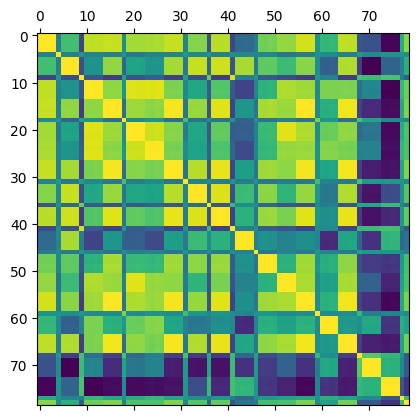

In [9]:
data2 = data.drop(columns=['Data'])
plt.matshow(data2.corr())

In [10]:
def plot_corr(df, size=10):
    corr = df.corr()
    fig, ax = plt.subplots(figsize=(size, size))
    ax.matshow(corr)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)

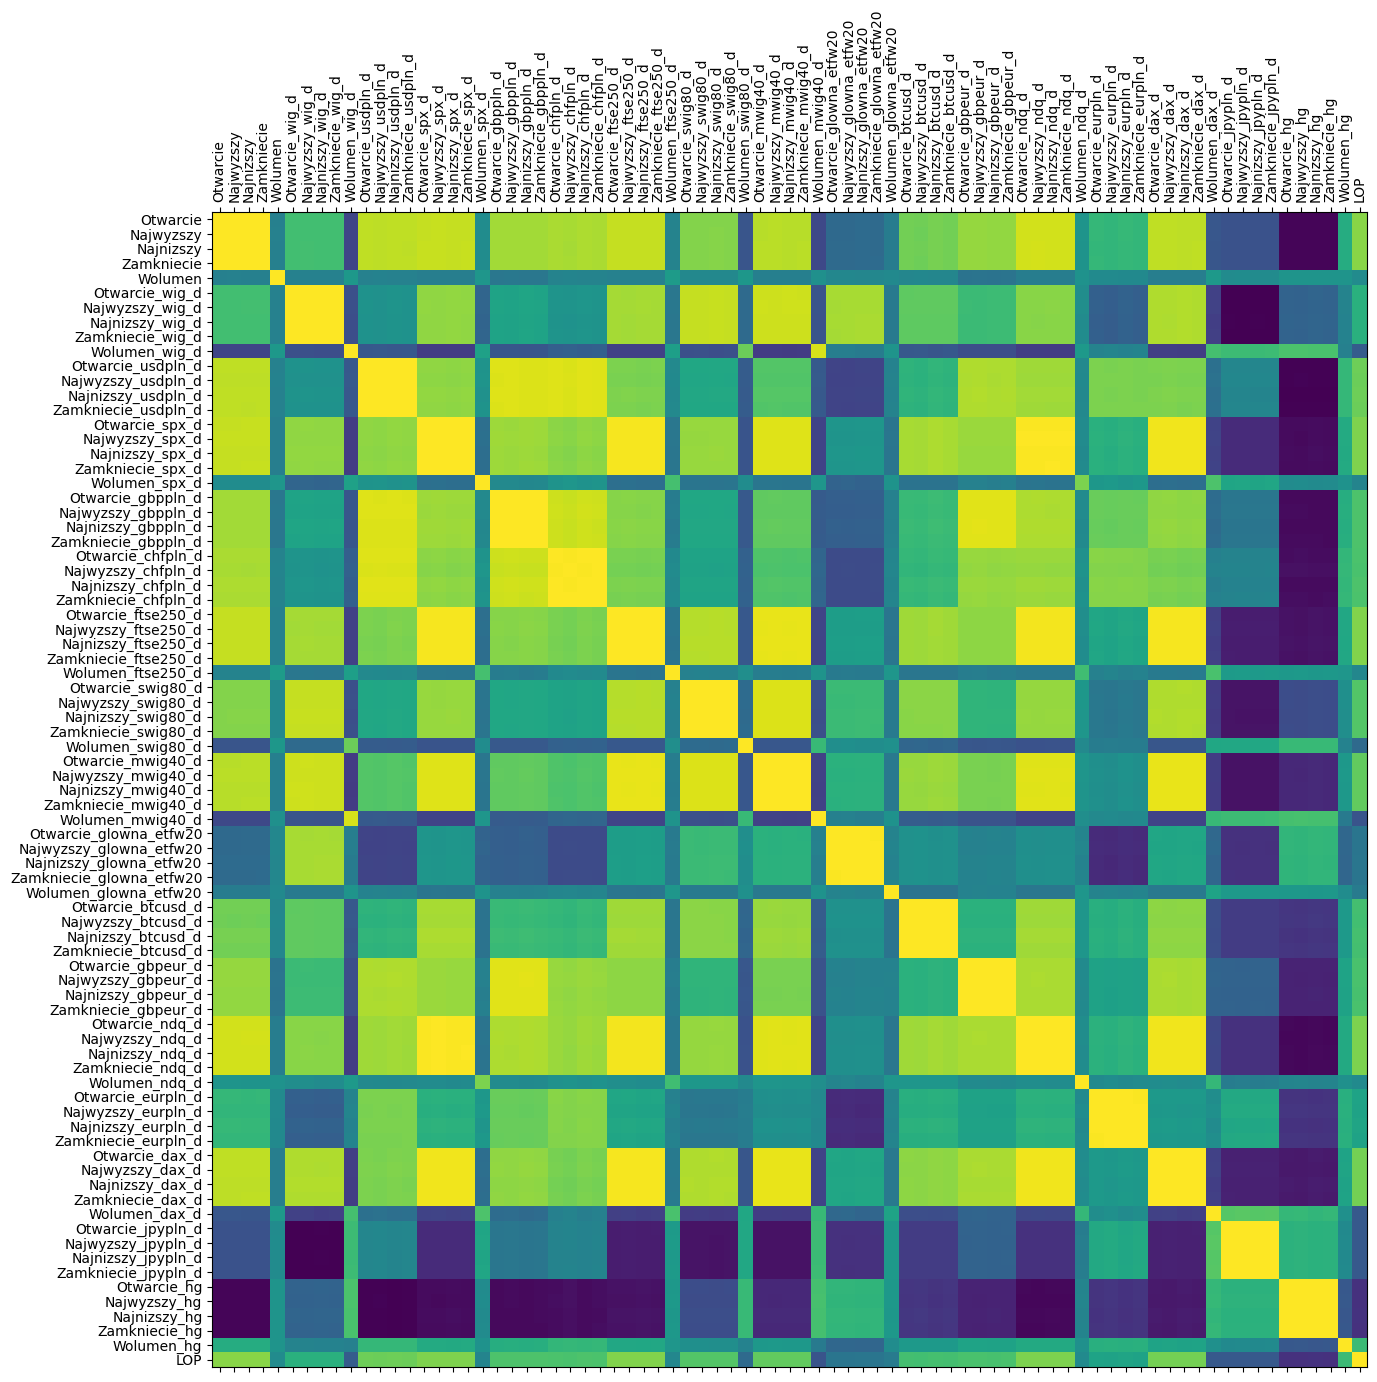

In [11]:
plot_corr(data2, 15)

In [ ]:
corr = data2.corr()
corr.style.background_gradient('Blues')

### Conclusions

Several strong correlations can be observed between variables representing the same stock index.

For example:
- Open, Close, High, and Low values for the same index (e.g., WIG, SPX, DAX) show very strong correlations.

This is expected because these variables describe different aspects of the same trading session.

### Strongest and Weakest Correlations

In [ ]:
corr_unstacked = corr.where(~np.eye(corr.shape[0], dtype=bool)) #~np.eye usuwa przekątną np: czyli (A, A)
corr_series = corr_unstacked.unstack().dropna()

# Usuwamy duplikaty (bo korelacja(A, B) == korelacja(B, A)) ~duplicated() usuwa powtórzenia zostawiamy tylko (A, B), pomijamy (B, A)
corr_series = corr_series[~corr_series.index.duplicated(keep='first')]


# Najsilniejsza i Najslabsza korelacja
max_abs_index = corr_series.abs().idxmax()
max_corr = corr_series[max_abs_index]
min_abs_index = corr_series.abs().idxmin()
min_corr = corr_series[min_abs_index]

print("Najsilniejsza korelacja:", max_corr)
print("Najslabsza korelacja:", min_corr)

Najsilniejsza korelacja: 0.9997677786563125
Najslabsza korelacja: -0.00013404735021558598


## 6. Model Construction

### Reloading the prepared dataset

The previously prepared dataset is loaded again for model training.

In [ ]:
# data = pd.read_csv('combined_data.csv') loaded again with the deleted NaN values

In [ ]:
print("Number of rows , columns :", data.shape)

Number of rows , columns : (1328, 80)


### Creating the training dataset

The dataset is split into three subsets:

- **Training set** – used to train the neural network
- **Validation set** – used to evaluate the model during training
- **Test set** – used for final evaluation of model performance

In [ ]:
# training set
ratio = 0.6  # dimension aspect ratio (0.6 over the entire dataset)
N = int(len(data)*ratio)   # lnumber of samples per class
train_df, test_df = data[:N], data[N:]   # assignment of samples to variables
print(train_df.shape)

(796, 80)


In [ ]:
# test set
ratio = 0.5
N = int(len(data)*ratio)
test_df, val_df = test_df[:N], test_df[N:]
print(test_df.shape)

(532, 80)


In [ ]:
train_df.describe()

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen,Otwarcie_wig_d,Najwyzszy_wig_d,Najnizszy_wig_d,Zamkniecie_wig_d,Wolumen_wig_d,...,Otwarcie_jpypln_d,Najwyzszy_jpypln_d,Najnizszy_jpypln_d,Zamkniecie_jpypln_d,Otwarcie_hg,Najwyzszy_hg,Najnizszy_hg,Zamkniecie_hg,Wolumen_hg,LOP
count,796.000000,796.000000,796.000000,796.000000,7.960000e+02,796.000000,796.000000,796.000000,796.000000,7.960000e+02,...,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000
mean,275.481947,278.922935,272.110906,275.665881,3.829253e+06,45469.650163,45702.456106,45178.879611,45460.640214,1.115163e+08,...,3.616195,3.643789,3.592997,3.617381,363.213342,366.972161,359.210741,363.236709,59753.991206,150184.608040
std,73.790815,75.096513,72.750263,74.075311,2.002616e+06,4498.439528,4469.965208,4533.549531,4502.835745,5.185918e+07,...,0.442465,0.448476,0.436036,0.443352,39.819839,40.348999,39.361206,40.058652,21071.309619,16233.734021
min,183.657000,185.595000,182.248000,184.759000,6.354160e+05,35921.430000,37158.450000,35761.420000,36720.770000,3.487371e+07,...,2.857900,2.867600,2.847400,2.857700,292.000000,296.200000,287.700000,292.100000,17880.000000,112315.000000
25%,216.566500,218.650750,213.923750,216.015000,2.588952e+06,41445.842500,41648.730000,41179.540000,41455.170000,7.877333e+07,...,3.259825,3.287725,3.245100,3.264050,331.275000,334.500000,328.175000,331.100000,46310.250000,141825.500000
50%,256.724000,260.660000,253.169000,257.289000,3.313409e+06,46101.810000,46305.120000,45898.475000,46120.060000,1.001794e+08,...,3.499100,3.526500,3.477950,3.499300,354.900000,359.150000,351.350000,354.950000,56057.500000,151865.500000
75%,307.032500,311.044250,300.795250,306.962000,4.396208e+06,48542.595000,48725.905000,48287.757500,48557.190000,1.299866e+08,...,4.022850,4.061650,3.995800,4.023225,387.300000,391.310000,382.650000,387.575000,70828.750000,160380.250000
max,474.645000,482.852000,471.811000,481.719000,1.695518e+07,55281.870000,55384.830000,55010.030000,55246.400000,6.491139e+08,...,4.564400,4.632400,4.532600,4.571800,463.100000,464.500000,454.350000,463.100000,172794.000000,194877.000000


In [ ]:
# provides calculations in a rolling window.
# windows = moving window size, this is the number of observations used to calculate the statistic.
# each window will be a fixed size.
rolling = data.rolling(window=7)

The model will be trained to predict **closing prices**.

In [ ]:
data_roll = pd.DataFrame()
data_roll['Zamkniecie']=train_df['Zamkniecie']

### Moving Average

A moving average is calculated to smooth short-term fluctuations and highlight long-term trends.

The window size can be adjusted using the parameter `lw`, which determines how many previous observations are included in the calculation.

In [ ]:
@widgets.interact_manual(lw=(1, 100))
def plot(lw):
  rolling = data.rolling(window=lw, center=True)
  data_roll = pd.DataFrame()

  data_roll['Zamkniecie']=data['Zamkniecie']
  data_roll['7 days rolling_mean(srednia kroczaca)']=data_roll['Zamkniecie'].rolling(lw, min_periods=1).mean()
  ax = data_roll.plot(style=['-', '--'], rot=90, figsize=(20, 10))
  ax.lines[0].set_alpha(0.3)

interactive(children=(IntSlider(value=50, description='lw', min=1), Button(description='Run Interact', style=B…

### LSTM Model

Predictions will be generated using a **Long Short-Term Memory (LSTM)** neural network, which is designed to model sequential data and capture temporal dependencies.

In [ ]:
aticipated_variable = "Zamkniecie"

def prepare_dataset_to_lstm(aticipated_variable, train_df, ratio):
  dataset = train_df[aticipated_variable].values
  dataset = dataset.astype('float32')
  dataset = np.reshape(dataset, (-1, 1))
  scaler = MinMaxScaler(feature_range=(0, 1))
  dataset = scaler.fit_transform(dataset)

  train_size = int(len(dataset) * ratio)
  test_size = len(dataset) - train_size
  train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

  return train, test, scaler

train, test, scaler = prepare_dataset_to_lstm(aticipated_variable, train_df, ratio=0.8)

## 7. Model Training

A helper function is defined to transform the dataset into matrices suitable for training the LSTM model.

Parameters:
- **dataset** – the prepared dataset
- **look_back** – number of previous time steps used to predict the next value (set to 20)

In [ ]:
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 20
X_train, Y_train = create_dataset_lstm(train, look_back)
X_test, Y_test = create_dataset_lstm(test, look_back)

X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

print(X_train.shape)
print(X_test.shape)

(615, 1, 20)
(139, 1, 20)


### Model Architecture

The model is implemented using a **Sequential** architecture.

Components:
- LSTM layer with 20 neurons
- Dropout layer to prevent overfitting
- Dense output layer

Dropout randomly disables some neurons during training, which helps prevent the model from memorizing the training data.

In [ ]:
def lstm_model(X_train, Y_train, X_test, Y_test, batch_size=20):
  model = Sequential()
  model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
  model.add(Dropout(0.2))
  model.add(Dense(1))

  model.compile(loss='mean_squared_error', optimizer='adam')

  history = model.fit(X_train, Y_train, epochs=500, batch_size=20, validation_data=(X_test, Y_test),
                      callbacks=[EarlyStopping(monitor='val_loss', patience=10)], verbose=1, shuffle=False)
  return model, history

### Model Evaluation

In [ ]:
def evaluation_model(model, X_train, X_test, Y_train, testing=True):
    # Skalowanie danych wyjściowych
    scaler = MinMaxScaler(feature_range=(0, 1))
    Y_train_scaled = scaler.fit_transform(Y_train.reshape(-1, 1))

    train_predict = model.predict(X_train)
    test_predict = model.predict(X_test)

    if train_predict.ndim == 3:
        train_predict = np.squeeze(train_predict, axis=-1)
    if test_predict.ndim == 3:
        test_predict = np.squeeze(test_predict, axis=-1)
    if Y_train.ndim == 3:
        Y_train = np.squeeze(Y_train, axis=-1)

    _mean_absolute_error = mean_absolute_error(Y_train, train_predict)
    _mean_squared_error = np.sqrt(mean_squared_error(Y_train, train_predict))

    print('Train Mean Absolute Error:', _mean_absolute_error)
    print('Train Root Mean Squared Error:', _mean_squared_error)

    if testing:
        return Y_train, train_predict, _mean_absolute_error, _mean_squared_error
    return Y_train, train_predict


We observe that both:

- **loss** (training loss)
- **val_loss** (validation loss)

decrease as the number of epochs increases. This indicates that the model is successfully learning patterns from the data.

In [ ]:
history, true_history = lstm_model(X_train, Y_train, X_test, Y_test, batch_size=20)

Epoch 1/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1365 - val_loss: 0.4915
Epoch 2/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0687 - val_loss: 0.1972
Epoch 3/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0459 - val_loss: 0.0708
Epoch 4/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0349 - val_loss: 0.0311
Epoch 5/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0296 - val_loss: 0.0291
Epoch 6/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0283 - val_loss: 0.0230
Epoch 7/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0300 - val_loss: 0.0175
Epoch 8/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0291 - val_loss: 0.0197
Epoch 9/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0263 - val_loss: 0.0167
Epoch 10/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0244 - val_loss: 0.0209
Epoch 11/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0334 - val_loss: 0.0138
Epoch 12/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

### Saving the Model

The trained neural network model is saved in **JSON format** for future use.

In [ ]:
model_json = history.to_json()  #saving the history model to JSON
with open("model.json", "w") as json_file:  #create a model.json file in edit mode and keep it in a variable: json_file
    json_file.write(model_json)
# saving weight from the model using a function: save.weights.
history.save_weights("model.weights.h5")  #weights are saved in the model.h5 file in the local directory.
print("Saved model to disk")  #comment on successful operation

Saved model to disk


In [ ]:
evaluation_model(history,X_train, X_test, Y_train)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Train Mean Absolute Error: 0.02998306229710579
Train Root Mean Squared Error: 0.04054775212511527


(array([0.30280167, 0.30280167, 0.30186558, 0.28990775, 0.2862473 ,
        0.25676858, 0.242962  , 0.27149117, 0.29358834, 0.2816406 ,
        0.28806907, 0.28990775, 0.30001682, 0.29450428, 0.29540682,
        0.31568223, 0.32304692, 0.32855606, 0.3055361 , 0.3064723 ,
        0.30463362, 0.28254986, 0.29358834, 0.30186558, 0.3110789 ,
        0.31568223, 0.3064723 , 0.33039802, 0.34603995, 0.3340922 ,
        0.3340922 , 0.32488889, 0.31843013, 0.3221107 , 0.31383348,
        0.30463362, 0.32949555, 0.32855606, 0.31658137, 0.33039802,
        0.36722118, 0.35708845, 0.35063308, 0.36996567, 0.3442012 ,
        0.34512395, 0.34697944, 0.3368333 , 0.33869553, 0.34052402,
        0.34974742, 0.33500475, 0.33869553, 0.3239494 , 0.30463362,
        0.32488889, 0.38008827, 0.41416353, 0.38287312, 0.39942747,
        0.41321725, 0.40034682, 0.39206296, 0.39206296, 0.3708985 ,
        0.37643123, 0.37273037, 0.36262125, 0.34236932, 0.3359207 ,
        0.32764345, 0.34697944, 0.3432718 , 0.35

In [ ]:
Y_train, train_predict, mae, mse = evaluation_model(history,X_train, X_test, Y_train)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Train Mean Absolute Error: 0.02998306229710579
Train Root Mean Squared Error: 0.04054775212511527


## 8. Visualization

A visualization function is created to illustrate how the model predictions compare to actual stock prices.

In [ ]:
def visualization(Y_train, train_predict):
  N = len(Y_train)
  aa=[x for x in range(N)]  # N denotes the number of features in the data point
  plt.figure(figsize=(8,4))
  plt.plot(aa, Y_train, marker='.', label="actual") #When . we change to * we will have instead of . -> *
  plt.plot(aa, train_predict[:,0], 'r', label="prediction")
  # plt.tick_params(left=False, labelleft=True) #remove ticks
  plt.tight_layout()  # adjust padding (dopełnienie) between and around support fields
  sns.despine(top=True) # we remove the ridge
  plt.subplots_adjust(left=0.07)  # the position of the left edge of the chart
  plt.title(" prediction")
  plt.xlabel('Time step', size=15)  # font size for time step 15
  plt.legend(fontsize=15)  # font size of legend items
  plt.show();  # we run event loops, search for all active figure objects and open one or more interactive windows.



Legend:

- **Blue line** – actual stock prices
- **Red line** – predicted values

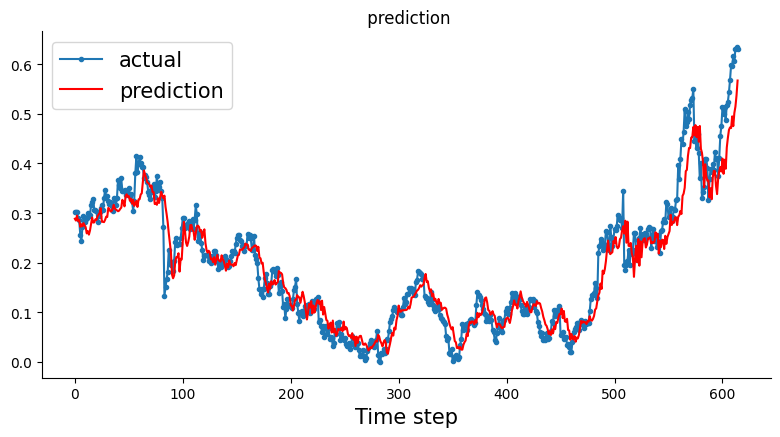

In [ ]:
# The data is not normalized in the chart
visualization(Y_train, train_predict)

### Conclusions

- The model successfully captures the overall trend in the data.
- Prediction accuracy is moderate at a local level.
- The LSTM model struggles to reproduce sudden spikes and drops, which is typical for smoothing models.

## 9. Model Evaluation and Interpretation

In [ ]:
def evaluation_model_test(model,X_test, Y_test, testing=True):

    test_predict = model.predict(X_test)

    if test_predict.ndim == 3:
        test_predict = np.squeeze(test_predict, axis=-1)

    if Y_test.ndim == 3:
        Y_test = np.squeeze(Y_test, axis=-1)

    _mean_absolute_error = mean_absolute_error(Y_test, test_predict)
    _mean_squared_error = np.sqrt(mean_squared_error(Y_test, test_predict))

    print('Test Mean Absolute Error:', _mean_absolute_error)
    print('Test Root Mean Squared Error:', _mean_squared_error)

    if testing:
        return Y_test, test_predict, _mean_absolute_error, _mean_squared_error
    return Y_test, test_predict

In [ ]:
Y_test, test_predict, _mean_absolute_error, _mean_squared_error = evaluation_model_test(history, X_test,  Y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Test Mean Absolute Error: 0.06873452663421631
Test Root Mean Squared Error: 0.08195383244782778


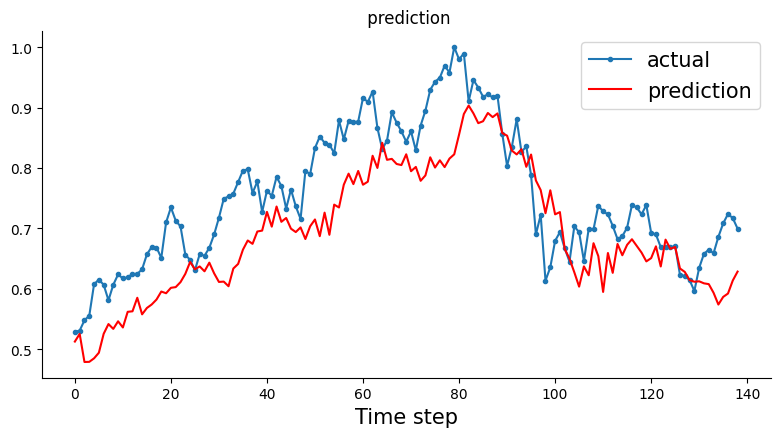

In [ ]:
# The data is not normalized in the chart
visualization(Y_test, test_predict)

### Conclusions

- The prediction curve is smoother and slightly delayed compared to real data.
- The model tends to underestimate peak values.
- Rapid market movements are difficult to capture accurately.

## Model Comparison

### Loss Curve Analysis

In [ ]:
def lstm_model_new(X_train, Y_train, X_test, Y_test, batch_size=64):  #  ZMIANA: większy batch_size (64) W kontekście giełdy, większy batch może lepiej uśredniać fluktuacje, co pomaga uczyć się ogólnych trendów, a nie przypadkowych wahań.

    model_new = Sequential()
    model_new.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
    model_new.add(LSTM(100, return_sequences=False))  #  ZMIANA: więcej jednostek LSTM pozwala modelowi uchwycić bardziej złożone wzorce czasowe, które są typowe dla danych giełdowych (np. trendy, sezony, mikrocykle)
    model_new.add(Dropout(0.25))                      #  ZMIANA: łagodniejszy dropout (mniejsze ryzyko nadmiernego wygładzania)
    model_new.add(Dense(1))

    model_new.compile(loss='mean_squared_error', optimizer='rmsprop')  #  ZMIANA: optymalizator RMSprop (lepszy dla szeregów czasowych)

    history_new = model_new.fit(
        X_train, Y_train,
        epochs=200,                                   #  ZMIANA: mniejsza liczba epok (szybsze zatrzymanie)
        batch_size=batch_size,
        validation_data=(X_test, Y_test),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10)],
        verbose=1, shuffle=False
    )

    return model_new, history_new

In [ ]:
model_new, history_new = lstm_model_new(X_train, Y_train, X_test, Y_test, batch_size=64)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0638 - val_loss: 0.0887
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0058 - val_loss: 0.0122
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0027 - val_loss: 0.0052
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0028 - val_loss: 0.0045
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0026 - val_loss: 0.0049
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025 - val_loss: 0.0047
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - val_loss: 0.0049
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0037
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0035
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0017 - val_loss: 0.0032
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0017 - val_loss: 0.0031
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

In [ ]:
model_json_new = model_new.to_json()
with open("model_new.json", "w") as json_file:
    json_file.write(model_json_new)
model_new.save_weights("model_new.weights.h5")
print("Saved NEW model to disk")

Saved NEW model to disk


In [ ]:
Y_train_new, train_predict_new, mae_new, rmse_new = evaluation_model(model_new, X_train, X_test, Y_train)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Train Mean Absolute Error: 0.02311764843761921
Train Root Mean Squared Error: 0.030707224951003212


In [ ]:
def visualization_new(Y_train, train_predict, train_predict_old=None):
    N = len(Y_train)
    aa = [x for x in range(N)]  # N denotes the number of features in the data point
    plt.figure(figsize=(8,4))
    plt.plot(aa, Y_train, marker='.', label="actual")  # When . we change to * we will have instead of . -> *
    plt.plot(aa, train_predict[:,0], 'r', label="prediction")

    if train_predict_old is not None:
        plt.plot(aa, train_predict_old[:,0], 'g--', label="old prediction")

    # plt.tick_params(left=False, labelleft=True) #remove ticks
    plt.tight_layout()  # adjust padding (dopełnienie) between and around support fields
    sns.despine(top=True)  # we remove the ridge
    plt.subplots_adjust(left=0.07)  # the position of the left edge of the chart
    plt.title(" prediction")
    plt.xlabel('Time step', size=15)  # font size for time step 15
    plt.legend(fontsize=15)  # font size of legend items
    plt.show();  # we run event loops, search for all active figure objects and open one or more interactive windows.

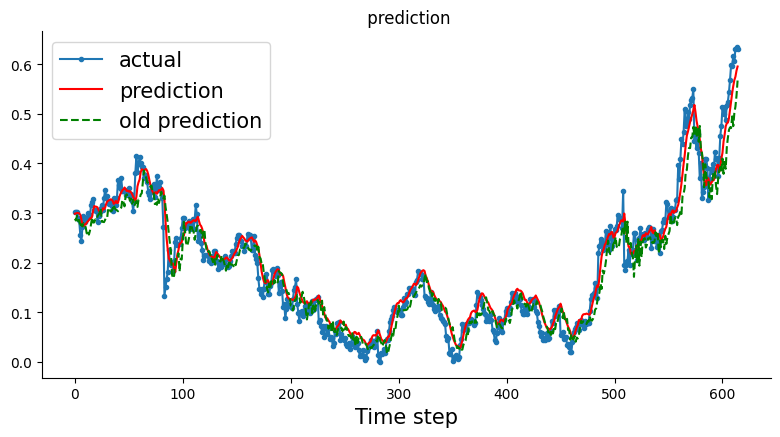

In [ ]:
visualization_new(Y_train_new, train_predict_new, train_predict)

Training loss decreases rapidly during the first epochs and stabilizes afterward.

Validation loss follows a similar pattern, suggesting that the model generalizes reasonably well without significant overfitting.

### Hyperparameter Optimization

In [ ]:
Y_test_new, test_predict_new, mae_test_new, rmse_test_new = evaluation_model_test(model_new, X_test, Y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Test Mean Absolute Error: 0.046402689069509506
Test Root Mean Squared Error: 0.055297641037967596


In [ ]:
r2 = r2_score(Y_test, test_predict)
r2_new = r2_score(Y_test_new, test_predict_new)

df_metryki= pd.DataFrame({
    "Model": ["Stary", "Nowy"],
    "R2": [r2, r2_new],
    "MAE": [_mean_absolute_error, mae_test_new],
    "RMSE": [_mean_squared_error, rmse_test_new]
})

print(df_metryki)

   Model        R2       MAE      RMSE
0  Stary  0.457694  0.068735  0.081954
1   Nowy  0.753101  0.046403  0.055298


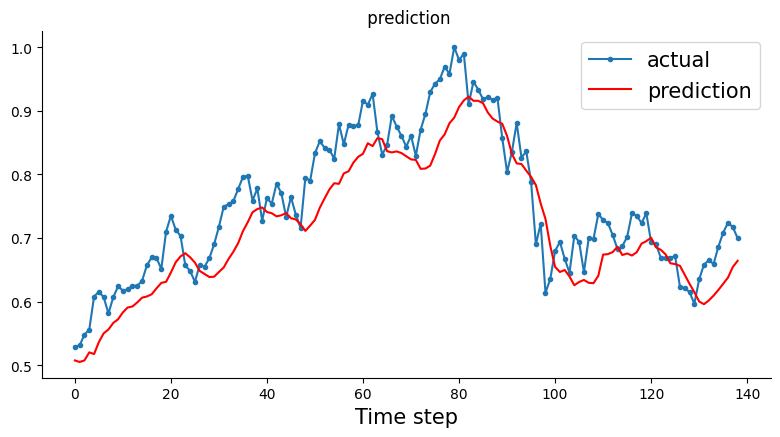

In [ ]:
visualization(Y_test_new, test_predict_new)

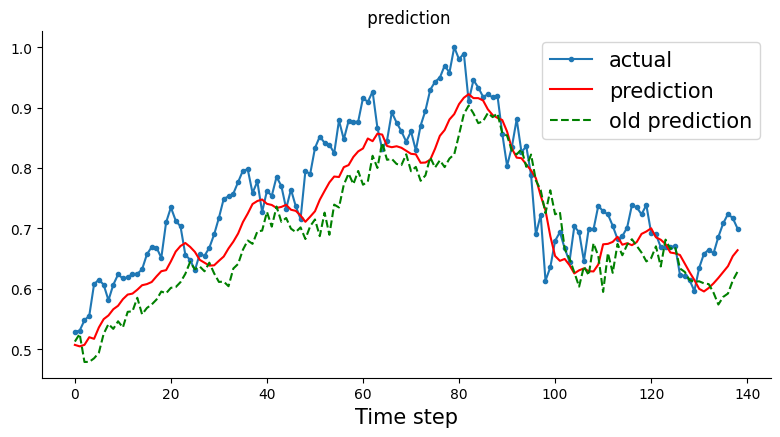

In [ ]:
visualization_new(Y_test_new, test_predict_new, test_predict)

1. Loss Curve Analysis
Old model:
<br> </br>Training loss (cyan, dashed):
- Start: ~0.9 → stabilization: 0.1–0.2 (after ~10 epochs)
- Well fitted to the training data, but limited in detecting complex patterns.
Validation loss (blue, solid):
- Start: ~0.9 → stabilization: ~0.1
- Good generalization, but worse than in the new model.
<br> </br>New model:
Training loss (green, dashed):
- Start: ~0.8 → decrease to ~0.0
- Very effective fit to the data.
Validation loss (red, solid):
- Start: ~0.6 → stabilization: 0.0–0.1
- Very good generalization on test data.
<br> </br>
2. Comparison of Architecture and Parameters
Model architecture:
<br> </br>Old model:
- Dropout + Dense (no LSTM)
- Limited ability to capture temporal dependencies.
<br> </br>New model:
- LSTM (100 units) → better detection of long-term dependencies.
<br> </br>
Optimizer:
<br> </br>Old model:
- Adam – general-purpose, but less stable for time series.
<br> </br>New model:
- RMSprop – better suited for sequential data, faster convergence.
<br> </br>
Dropout:
<br> </br>Old model:
- 0.2 on the input – may limit the amount of transmitted information.
<br> </br>New model:
- 0.25 after the LSTM layer – better balance between learning and generalization.
<br> </br>
Epochs and batch size:
<br> </br>Old model:
- 500 epochs, batch size 20 → higher risk of overfitting.
<br> </br>New model:
- 200 epochs, batch size 64 + EarlyStopping → stable and faster training.
<br> </br>
3. Final Conclusions
- The new model performs significantly better in predicting stock prices.
- More effective pattern detection thanks to the LSTM layer.
- Faster and more stable training due to RMSprop and larger batch sizes.
- Better generalization – very low validation loss.
- Despite producing acceptable results, the old model is too simplified and less effective for complex time series.

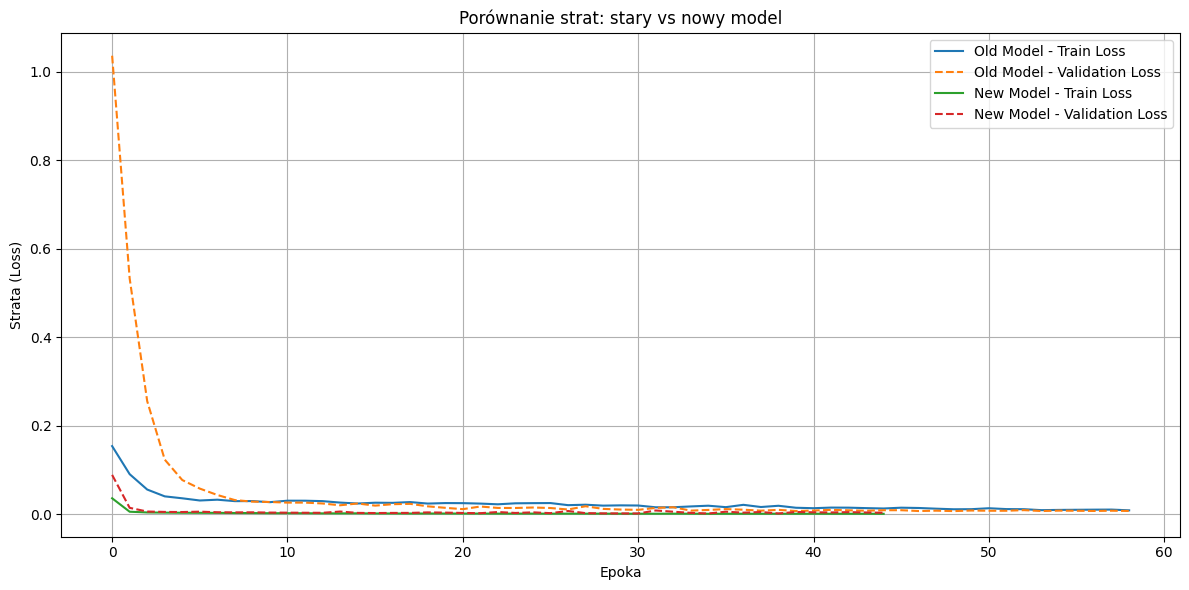

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(true_history.history['loss'], label='Old Model - Train Loss', linestyle='-')
plt.plot(true_history.history['val_loss'], label='Old Model - Validation Loss', linestyle='--')

plt.plot(history_new.history['loss'], label='New Model - Train Loss', linestyle='-')
plt.plot(history_new.history['val_loss'], label='New Model - Validation Loss', linestyle='--')

plt.title('Porównanie strat: stary vs nowy model')
plt.xlabel('Epoka')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
import numpy as np

def tune_lstm_models(
    X_train, Y_train, X_test, Y_test,
    units_list=[50, 100],             # Lista liczby neuronów w warstwie LSTM do przetestowania
    dropout_list=[0.2, 0.3],          # Lista wartości dropout (zapobieganie przeuczeniu)
    batch_sizes=[32, 64],             # Rozmiary batchy do treningu
    epochs=200,                      # Maksymalna liczba epok treningu
    patience=10,                     # Liczba epok bez poprawy na zbiorze walidacyjnym, po której zatrzymujemy trening (EarlyStopping)
    learning_rates=[0.001, 0.0005],  # Różne tempo uczenia (learning rate) do testowania
    optimizers=['rmsprop', 'adam'],  # Lista optymalizatorów do wyboru
    num_layers_list=[1, 2],          # Liczba warstw LSTM do testowania (wielowarstwowość)
    bidirectional_options=[False, True]  # Czy użyć warstw dwukierunkowych LSTM
):
    best_r2 = -np.inf
    best_model = None
    best_history = None
    best_params = {}

    # Pętla po wszystkich kombinacjach parametrów
    for units in units_list:
        for dropout in dropout_list:
            for batch_size in batch_sizes:
                for lr in learning_rates:
                    for opt_name in optimizers:
                        for num_layers in num_layers_list:
                            for bidir in bidirectional_options:
                                print(f"Trenuję model: units={units}, dropout={dropout}, batch_size={batch_size}, lr={lr}, optimizer={opt_name}, layers={num_layers}, bidirectional={bidir}")

                                # Wybór optymalizatora i ustawienie wartości learning rate
                                if opt_name == 'rmsprop':
                                    optimizer = RMSprop(learning_rate=lr)
                                elif opt_name == 'adam':
                                    optimizer = Adam(learning_rate=lr)

                                model = Sequential()
                                model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

                                # Dodanie warstw LSTM zgodnie z wybraną liczbą warstw
                                for i in range(num_layers):
                                    return_seq = (i < num_layers - 1)
                                    lstm_layer = LSTM(units, return_sequences=return_seq)

                                    # Opcjonalne owijanie warstwy LSTM w Bidirectional, jeśli zaznaczone
                                    if bidir:
                                        lstm_layer = Bidirectional(lstm_layer)

                                    model.add(lstm_layer)
                                    model.add(Dropout(dropout))

                                model.add(Dense(1))

                                model.compile(loss='mean_squared_error', optimizer=optimizer)

                                history = model.fit(
                                    X_train, Y_train,
                                    epochs=epochs,
                                    batch_size=batch_size,
                                    validation_data=(X_test, Y_test),
                                    callbacks=[EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)],
                                    verbose=0,
                                    shuffle=False
                                )

                                # Predykcja na zbiorze testowym po treningu
                                Y_pred = model.predict(X_test)

                                # Obliczenie współczynnika determinacji R² na danych testowych
                                r2 = r2_score(Y_test, Y_pred)

                                print(f"R² dla tego modelu: {r2:.4f}")

                                if r2 > best_r2:
                                    best_r2 = r2
                                    best_model = model
                                    best_history = history
                                    best_params = {
                                        'units': units,
                                        'dropout': dropout,
                                        'batch_size': batch_size,
                                        'learning_rate': lr,
                                        'optimizer': opt_name,
                                        'num_layers': num_layers,
                                        'bidirectional': bidir,
                                        'r2': r2
                                    }


    return best_model, best_history, best_params

In [ ]:
best_model, best_history, best_params = tune_lstm_models(
    X_train, Y_train, X_test, Y_test,
    units_list=[50, 100],
    dropout_list=[0.2, 0.3],
    batch_sizes=[32, 64],
    epochs=100,
    patience=10,
    learning_rates=[0.001, 0.0005],
    optimizers=['rmsprop', 'adam'],
    num_layers_list=[1, 2],
    bidirectional_options=[False, True]
)

print("Najlepsze parametry znalezione przez tuning:")
print(best_params)

Trenuję model: units=50, dropout=0.2, batch_size=32, lr=0.001, optimizer=rmsprop, layers=1, bidirectional=False
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
R² dla tego modelu: 0.5773
Trenuję model: units=50, dropout=0.2, batch_size=32, lr=0.001, optimizer=rmsprop, layers=1, bidirectional=True
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
R² dla tego modelu: 0.8116
Trenuję model: units=50, dropout=0.2, batch_size=32, lr=0.001, optimizer=rmsprop, layers=2, bidirectional=False
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
R² dla tego modelu: 0.6815
Trenuję model: units=50, dropout=0.2, batch_size=32, lr=0.001, optimizer=rmsprop, layers=2, bidirectional=True
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step
R² dla tego modelu: 0.6304
Trenuję model: units=50, dropout=0.2, batch_size=32, lr=0.001, optimizer=adam, layers=1, bidirectional=False
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
R² dla tego modelu: 0.6357
Trenuję model: units=50, dropout=0.2, batch_size=32, lr=0.001, optimizer=adam, layers=1, bidirectional=True
5/5 ━━━━━━

In [ ]:
Y_test_best, test_predict_best, mae_test_best, rmse_test_best = evaluation_model_test(best_model, X_test, Y_test)
r2_best = r2_score(Y_test_best, test_predict_best)


df_metryki2= pd.DataFrame({
    "Model": ["Stary", "Nowy", "Najlepszy"],
    "R2": [r2, r2_new, r2_best],
    "MAE": [_mean_absolute_error, mae_test_new, mae_test_best],
    "RMSE": [_mean_squared_error, rmse_test_new, rmse_test_best]
})

print(df_metryki2)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Test Mean Absolute Error: 0.02790982276201248
Test Root Mean Squared Error: 0.03516176961908304
       Model        R2       MAE      RMSE
0      Stary  0.457694  0.068735  0.081954
1       Nowy  0.753101  0.046403  0.055298
2  Najlepszy  0.900173  0.027910  0.035162


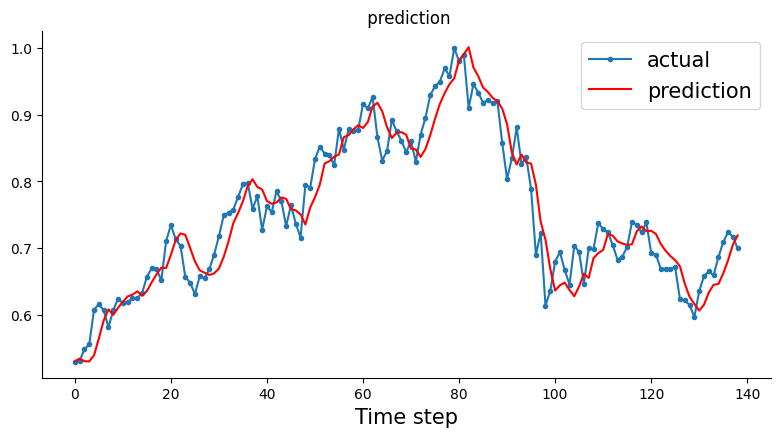

In [ ]:
visualization(Y_test_best, test_predict_best)

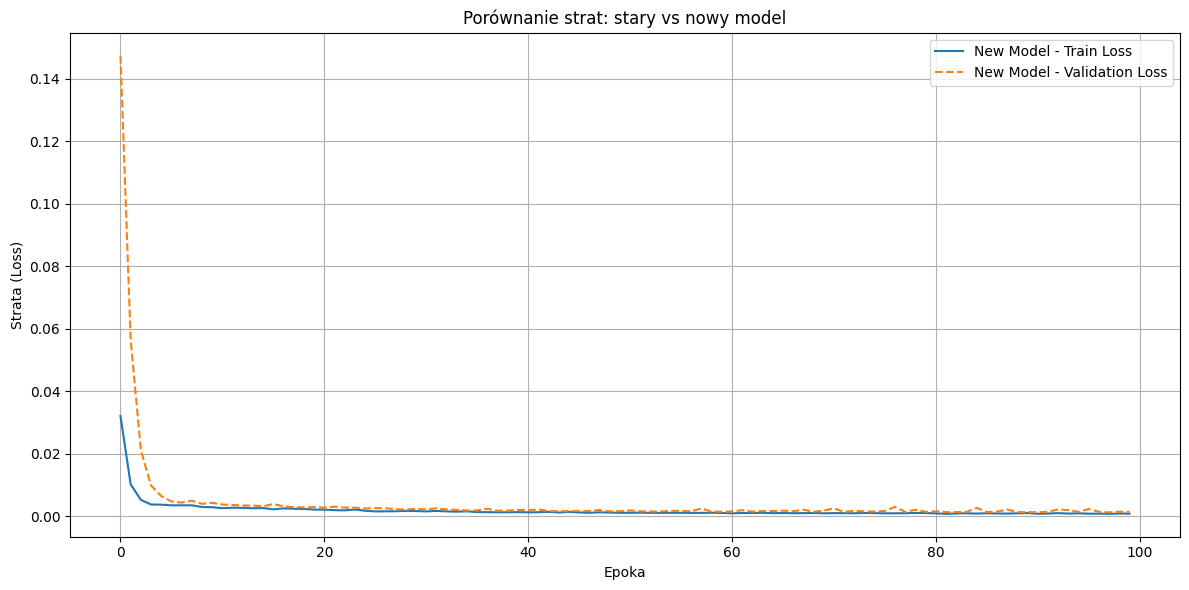

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(best_history.history['loss'], label='New Model - Train Loss', linestyle='-')
plt.plot(best_history.history['val_loss'], label='New Model - Validation Loss', linestyle='--')

plt.title('Porównanie strat: stary vs nowy model')
plt.xlabel('Epoka')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

A function was implemented to test different model parameters.

The best model is selected based on the **R² score**, but additional metrics such as:

- MAE
- RMSE

can also be included for more comprehensive evaluation.